# Insurance Type & ICU Length of Stay in Sepsis-3 Patients

**Research question:** Among adult ICU patients meeting Sepsis-3 criteria in MIMIC-IV, is insurance type associated with ICU length of stay, and does this association persist after adjustment for patient demographics and illness severity?

- **Primary outcome:** ICU length of stay (days)
- **Exposure:** Insurance type (Medicaid, Medicare, Private)
- **Primary cohort:** First qualifying Sepsis-3 ICU stay per patient
- **Primary model:** Gamma generalized linear model (GLM) with log link

This notebook documents cohort construction, exploratory analysis, sequential regression modeling, sensitivity analyses, robustness checks, and export of aggregate results for Tableau visualization.

## 1. Setup

Import required libraries and authenticate access to MIMIC-IV through Google BigQuery.

In [ ]:
from google.colab import auth
from google.cloud import bigquery

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import kruskal

auth.authenticate_user()

client = bigquery.Client(
    project="mimic-iv-portfolio-507520"
)

## 2. Cohort Extraction

Patients meeting the MIMIC-IV derived Sepsis-3 definition were identified and linked to ICU stay, hospital admission, and patient-level tables.

The extracted variables include ICU length of stay, insurance type, age, sex, race/ethnicity, SOFA score, admission type, and in-hospital mortality.

In [ ]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT stay_id) AS unique_icu_stays,
    COUNT(DISTINCT subject_id) AS unique_patients
FROM `physionet-data.mimiciv_3_1_derived.sepsis3`
WHERE sepsis3 = TRUE
"""

cohort_counts = client.query(query).to_dataframe()
cohort_counts

,total_rows,unique_icu_stays,unique_patients
0,32899,32899,25570


In [ ]:
query = """
SELECT
    s.subject_id,
    s.stay_id,
    i.hadm_id,

    -- Outcome
    i.intime AS icu_intime,
    i.los AS icu_los,

    -- Exposure
    a.insurance,

    -- Demographics
    p.gender,
    p.anchor_age AS age,
    a.race,

    -- Illness severity
    s.sofa_score,

    -- Admission characteristics
    a.admission_type,

    -- Secondary outcome
    a.hospital_expire_flag

FROM `physionet-data.mimiciv_3_1_derived.sepsis3` s

INNER JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
    ON s.stay_id = i.stay_id

INNER JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON i.hadm_id = a.hadm_id

INNER JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
    ON s.subject_id = p.subject_id

WHERE s.sepsis3 = TRUE
"""

df = client.query(query).to_dataframe()

df.head()

,subject_id,stay_id,hadm_id,icu_intime,icu_los,insurance,gender,age,race,sofa_score,admission_type,hospital_expire_flag
0,13917158,36392833,26576179,2133-10-08 01:25:00,1.026609,Medicaid,F,28,OTHER,2,EW EMER.,0
1,18037163,34019922,26697866,2132-11-27 19:13:05,2.838947,Medicaid,M,27,UNKNOWN,2,URGENT,0
2,14698776,30428102,29576630,2155-08-06 20:07:20,2.901806,Private,M,29,PATIENT DECLINED TO ANSWER,2,EW EMER.,0
3,15114658,33380345,23615392,2119-11-13 16:26:40,7.072558,Medicaid,F,36,BLACK/AFRICAN AMERICAN,2,EW EMER.,0
4,18141668,33117317,26401951,2118-10-15 08:03:00,10.430417,Medicaid,M,29,UNKNOWN,2,EW EMER.,0


In [ ]:
# Validate the extracted cohort
print("Rows:", len(df))
print("Unique ICU stays:", df["stay_id"].nunique())
print("Unique patients:", df["subject_id"].nunique())

print()
print("Missing values:")
print(
    df[["insurance", "age", "gender", "race", "sofa_score", "icu_los"]]
    .isna()
    .sum()
)

print()
print("Insurance categories:")
print(df["insurance"].value_counts(dropna=False))

Rows: 32899
Unique ICU stays: 32899
Unique patients: 25570

Missing values:
insurance     447
age             0
gender          0
race            0
sofa_score      0
icu_los         0
dtype: int64

Age summary:
count      32899.0
mean     64.725888
std      15.976537
min           18.0
25%           55.0
50%           66.0
75%           77.0
max           91.0
Name: age, dtype: Float64

Gender:
gender
M    19028
F    13871
Name: count, dtype: int64


## 3. Cohort Construction

The analysis was restricted to patients with Medicare, Medicaid, or private insurance.

Because some patients experienced multiple qualifying ICU stays, the **primary analysis uses only the first qualifying ICU stay per patient**. This produces one observation per patient and prevents patients with repeated ICU admissions from contributing disproportionately to the primary model.

All qualifying ICU stays are retained for a sensitivity analysis using patient-clustered standard errors.

In [ ]:
analysis_df = df[
    df["insurance"].isin(["Medicare", "Medicaid", "Private"])
].copy()

stay_counts = analysis_df.groupby("subject_id").size()

print("Qualifying ICU stays:", len(analysis_df))
print("Unique patients:", analysis_df["subject_id"].nunique())
print("Patients with >1 qualifying ICU stay:", (stay_counts > 1).sum())
print(
    "Percent of patients with >1 stay:",
    round((stay_counts > 1).mean() * 100, 2)
)

primary_df = (
    analysis_df
    .sort_values(["subject_id", "icu_intime"])
    .drop_duplicates(subset="subject_id", keep="first")
    .copy()
)

print()
print("Primary cohort rows:", len(primary_df))
print("Unique patients:", primary_df["subject_id"].nunique())
print("Unique ICU stays:", primary_df["stay_id"].nunique())
print()
print("Insurance:")
print(primary_df["insurance"].value_counts())

Primary cohort rows: 24534
Unique patients: 24534
Unique ICU stays: 24534

Insurance:
insurance
Medicare    14757
Private      6291
Medicaid     3486
Name: count, dtype: int64


## 4. Exploratory Analysis

Descriptive statistics are reported for the primary cohort (first qualifying Sepsis-3 ICU stay per patient).

In [ ]:
summary_primary = (
    primary_df
    .groupby("insurance", observed=True)
    .agg(
        n=("subject_id", "count"),
        age_mean=("age", "mean"),
        age_median=("age", "median"),
        sofa_mean=("sofa_score", "mean"),
        sofa_median=("sofa_score", "median"),
        los_mean=("icu_los", "mean"),
        los_median=("icu_los", "median"),
        mortality_pct=("hospital_expire_flag", lambda x: x.mean() * 100)
    )
    .round(2)
)

summary_primary

,n,age_mean,age_median,sofa_mean,sofa_median,los_mean,los_median,mortality_pct
insurance,,,,,,,,
Medicaid,3486,52.24,53.0,3.73,3.0,5.58,2.94,14.54
Medicare,14757,73.46,75.0,3.54,3.0,4.87,2.82,17.77
Private,6291,54.99,57.0,3.6,3.0,5.39,2.81,11.44


In [ ]:
# Distributional summary of ICU length of stay in the primary cohort
print("LOS percentiles:")
print(
    primary_df["icu_los"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print()
print("Skewness:", primary_df["icu_los"].skew())
print("Maximum ICU LOS:", primary_df["icu_los"].max())

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(primary_df["icu_los"], bins=100)
plt.xlabel("ICU Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.title("Distribution of ICU Length of Stay in the Primary Cohort")
plt.show()

ICU LOS is positive and strongly right-skewed, with a long upper tail. This motivates a Gamma GLM with a log link rather than ordinary linear regression on raw LOS.

## 5. Unadjusted Analysis

A Kruskal-Wallis test was used as a nonparametric comparison of ICU LOS distributions across the three payer groups.

In [ ]:
#unadjusted primary analysis, kruskal-wallis test

#null: no difference in LOS distribution between insurance groups, alt: at least one distribution is different from others

from scipy.stats import kruskal

medicaid_los = primary_df.loc[
    primary_df["insurance"] == "Medicaid", "icu_los"
]

medicare_los = primary_df.loc[
    primary_df["insurance"] == "Medicare", "icu_los"
]

private_los = primary_df.loc[
    primary_df["insurance"] == "Private", "icu_los"
]

h_stat, p_value = kruskal(
    medicaid_los,
    medicare_los,
    private_los
)

print("Kruskal-Wallis H:", h_stat)
print("p-value:", p_value)

Kruskal-Wallis H: 12.327822080502735
p-value: 0.0021040082978879275


The Kruskal-Wallis test indicated that ICU LOS distributions differed across insurance groups in the unadjusted analysis (H = 12.33, p = 0.002).

This test does not identify which payer groups differ and does not account for differences in patient characteristics or illness severity. Adjusted regression models were therefore used for the primary inferential analysis.

## 6. Covariate Preparation

Race/ethnicity and admission-type categories were consolidated before regression modeling to avoid sparse indicator variables and improve interpretability.

In [ ]:
#collapse race, too many variables

def categorize_race(race):
    race = str(race).upper()

    if "WHITE" in race:
        return "White"
    elif "BLACK" in race:
        return "Black"
    elif "HISPANIC" in race:
        return "Hispanic/Latino"
    elif "ASIAN" in race:
        return "Asian"
    elif race in ["UNKNOWN", "UNABLE TO OBTAIN", "PATIENT DECLINED TO ANSWER"]:
        return "Unknown/Declined"
    else:
        return "Other"

primary_df["race_group"] = primary_df["race"].apply(categorize_race)

primary_df["race_group"].value_counts()

,count
race_group,
White,16749
Unknown/Declined,3147
Black,2141
Other,1001
Hispanic/Latino,786
Asian,710


In [ ]:
#collapse admission type

def categorize_admission(admission):
    if admission in ["EW EMER.", "DIRECT EMER."]:
        return "Emergency"
    elif admission == "URGENT":
        return "Urgent"
    elif admission in ["ELECTIVE", "SURGICAL SAME DAY ADMISSION"]:
        return "Elective/Surgical"
    elif "OBSERVATION" in admission:
        return "Observation"
    else:
        return "Other"

primary_df["admission_group"] = (
    primary_df["admission_type"].apply(categorize_admission)
)

primary_df["admission_group"].value_counts()

,count
admission_group,
Emergency,13473
Urgent,5029
Elective/Surgical,3685
Observation,2347


## 7. Gamma GLM Analysis

ICU LOS is positive and strongly right-skewed. Gamma generalized linear models with a log link were therefore used to estimate multiplicative differences in expected ICU LOS.

Private insurance serves as the reference group.

Three sequential models were fitted:

1. **Unadjusted:** insurance only
2. **Demographic-adjusted:** insurance + age + sex + race/ethnicity
3. **Fully adjusted:** demographic covariates + SOFA score + admission type

Exponentiated insurance coefficients are reported as **LOS ratios**. A ratio >1 indicates longer expected LOS relative to privately insured patients; a ratio <1 indicates shorter expected LOS.

In [ ]:
model1 = smf.glm(
    formula='icu_los ~ C(insurance, Treatment(reference="Private"))',
    data=primary_df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

model2 = smf.glm(
    formula="""
        icu_los ~
        C(insurance, Treatment(reference="Private"))
        + age
        + C(gender)
        + C(race_group)
    """,
    data=primary_df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

model3 = smf.glm(
    formula="""
        icu_los ~
        C(insurance, Treatment(reference="Private"))
        + age
        + C(gender)
        + C(race_group)
        + sofa_score
        + C(admission_group)
    """,
    data=primary_df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

In [ ]:
models = {
    "Unadjusted": model1,
    "Demographic-adjusted": model2,
    "Fully adjusted": model3
}

rows = []

for model_name, model in models.items():
    for payer in ["Medicaid", "Medicare"]:
        term = (
            'C(insurance, Treatment(reference="Private"))'
            f'[T.{payer}]'
        )
        ci = model.conf_int().loc[term]
        rows.append({
            "Model": model_name,
            "Insurance": payer,
            "Reference": "Private",
            "LOS Ratio": np.exp(model.params[term]),
            "CI Lower": np.exp(ci[0]),
            "CI Upper": np.exp(ci[1]),
            "p-value": model.pvalues[term]
        })

model_estimates = pd.DataFrame(rows)
model_estimates.round(4)

,model,insurance,reference,los_ratio,ci_lower,ci_upper,p_value
0,Unadjusted,Medicaid,Private,1.0358,0.9824,1.0920,0.1927
1,Unadjusted,Medicare,Private,0.9044,0.8709,0.9392,0.0000
2,Demographic-adjusted,Medicaid,Private,1.0146,0.9617,1.0704,0.5956
3,Demographic-adjusted,Medicare,Private,1.0021,0.9589,1.0473,0.9252
4,Fully adjusted,Medicaid,Private,0.9925,0.9405,1.0475,0.7853
5,Fully adjusted,Medicare,Private,0.9887,0.9458,1.0335,0.6150


### Primary result

In the unadjusted Gamma model, Medicare coverage was associated with shorter expected ICU LOS relative to private insurance. After adjustment for demographics, that association moved essentially to the null and remained nonsignificant in the fully adjusted model. Medicaid was not significantly associated with ICU LOS in any model.

## 8. Sensitivity & Robustness Analyses

Two additional analyses were used to assess whether the primary conclusion depended on cohort definition or model specification.

In [ ]:
analysis_df["race_group"] = analysis_df["race"].apply(categorize_race)
analysis_df["admission_group"] = analysis_df["admission_type"].apply(categorize_admission)

sensitivity_model = smf.glm(
    formula="""
        icu_los ~
        C(insurance, Treatment(reference="Private"))
        + age
        + C(gender)
        + C(race_group)
        + sofa_score
        + C(admission_group)
    """,
    data=analysis_df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit(
    cov_type="cluster",
    cov_kwds={"groups": analysis_df["subject_id"]}
)

sensitivity_results = pd.DataFrame({
    "Coefficient": sensitivity_model.params,
    "LOS Ratio": np.exp(sensitivity_model.params),
    "p-value": sensitivity_model.pvalues,
    "CI Lower": np.exp(sensitivity_model.conf_int()[0]),
    "CI Upper": np.exp(sensitivity_model.conf_int()[1])
})

sensitivity_results.loc[
    sensitivity_results.index.str.contains("insurance")
].round(4)

,Coefficient,LOS Ratio,p-value,CI Lower,CI Upper
"C(insurance, Treatment(reference=""Private""))[T.Medicaid]",-0.011823,0.988247,0.647381,0.939430,1.039601
"C(insurance, Treatment(reference=""Private""))[T.Medicare]",-0.024475,0.975822,0.246885,0.936222,1.017097


The sensitivity analysis retained all qualifying ICU stays and used patient-clustered standard errors to account for repeated observations within patients. The payer estimates remained close to 1.0 and nonsignificant, consistent with the primary analysis.

### Model Diagnostics

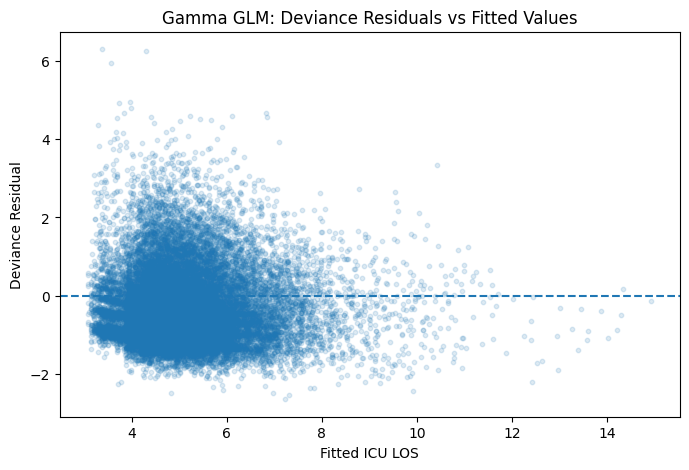

In [ ]:
primary_df["fitted_gamma"] = model3.fittedvalues
primary_df["gamma_resid"] = model3.resid_deviance

plt.figure(figsize=(8, 5))
plt.scatter(
    primary_df["fitted_gamma"],
    primary_df["gamma_resid"],
    alpha=0.15,
    s=10
)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted ICU LOS")
plt.ylabel("Deviance Residual")
plt.title("Gamma GLM: Deviance Residuals vs Fitted Values")
plt.show()

Deviance residuals were inspected against fitted values to assess systematic patterns in model fit and potential departures from the assumed mean-variance relationship.

### Alternative Model Specification: Log-LOS OLS

In [ ]:
primary_df["log_icu_los"] = np.log(primary_df["icu_los"])

log_ols = smf.ols(
    formula="""
        log_icu_los ~
        C(insurance, Treatment(reference="Private"))
        + age
        + C(gender)
        + C(race_group)
        + sofa_score
        + C(admission_group)
    """,
    data=primary_df
).fit(cov_type="HC3")

log_results = pd.DataFrame({
    "Coefficient": log_ols.params,
    "Ratio": np.exp(log_ols.params),
    "p-value": log_ols.pvalues,
    "CI Lower": np.exp(log_ols.conf_int()[0]),
    "CI Upper": np.exp(log_ols.conf_int()[1])
})

log_results.loc[
    log_results.index.str.contains("insurance")
].round(4)

,Coefficient,Ratio,p-value,CI Lower,CI Upper
"C(insurance, Treatment(reference=""Private""))[T.Medicaid]",-0.016550,0.983586,0.436365,0.943437,1.025444
"C(insurance, Treatment(reference=""Private""))[T.Medicare]",0.005665,1.005682,0.739154,0.972697,1.039785


The log-transformed OLS robustness model produced the same substantive conclusion: neither Medicaid nor Medicare was significantly associated with ICU LOS after adjustment.

## 9. Results Visualization

The forest plot below is generated directly from the fitted model objects so that the visualization and exported model estimates use a single source of truth.

In [ ]:
plot_order = [
    ("Medicaid", "Unadjusted"),
    ("Medicaid", "Demographic-adjusted"),
    ("Medicaid", "Fully adjusted"),
    ("Medicare", "Unadjusted"),
    ("Medicare", "Demographic-adjusted"),
    ("Medicare", "Fully adjusted")
]

plot_data = model_estimates.copy()
plot_data["order"] = plot_data.apply(
    lambda r: plot_order.index((r["Insurance"], r["Model"])), axis=1
)
plot_data = plot_data.sort_values("order")
plot_data["Label"] = plot_data["Insurance"] + " — " + plot_data["Model"]

y = np.arange(len(plot_data))
xerr = np.vstack([
    plot_data["LOS Ratio"] - plot_data["CI Lower"],
    plot_data["CI Upper"] - plot_data["LOS Ratio"]
])

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    plot_data["LOS Ratio"],
    y,
    xerr=xerr,
    fmt="o",
    capsize=4
)
ax.axvline(1, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(plot_data["Label"])
ax.set_xlabel("ICU Length-of-Stay Ratio (95% CI)")
ax.set_title("Association Between Insurance Type and ICU Length of Stay")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Dashboard Data Export

Only aggregate cohort summaries, model estimates, and dashboard-level KPIs are exported for Tableau. Patient-level MIMIC-IV data are not exported for public visualization.

In [ ]:
payer_summary = (
    primary_df
    .groupby("insurance", observed=True)
    .agg(
        patients=("subject_id", "count"),
        mean_age=("age", "mean"),
        median_age=("age", "median"),
        mean_sofa=("sofa_score", "mean"),
        median_sofa=("sofa_score", "median"),
        mean_los=("icu_los", "mean"),
        median_los=("icu_los", "median"),
        q1_los=("icu_los", lambda x: x.quantile(0.25)),
        q3_los=("icu_los", lambda x: x.quantile(0.75)),
        mortality_pct=("hospital_expire_flag", lambda x: x.mean() * 100)
    )
    .reset_index()
    .round(2)
)

dashboard_kpis = pd.DataFrame({
    "patients": [primary_df["subject_id"].nunique()],
    "median_los": [primary_df["icu_los"].median()],
    "median_sofa": [primary_df["sofa_score"].median()],
    "mortality_pct": [primary_df["hospital_expire_flag"].mean() * 100]
}).round(2)

# Reuse the model_estimates table produced above, with Tableau-friendly column names
model_estimates_export = model_estimates.rename(columns={
    "Model": "model",
    "Insurance": "insurance",
    "Reference": "reference",
    "LOS Ratio": "los_ratio",
    "CI Lower": "ci_lower",
    "CI Upper": "ci_upper",
    "p-value": "p_value"
})

payer_summary.to_csv("payer_summary.csv", index=False)
model_estimates_export.to_csv("model_estimates.csv", index=False)
dashboard_kpis.to_csv("dashboard_kpis.csv", index=False)

print("Exported aggregate Tableau files:")
print("- payer_summary.csv")
print("- model_estimates.csv")
print("- dashboard_kpis.csv")

## 11. Key Findings

Insurance groups differed in ICU length of stay in unadjusted analyses. Medicare patients initially appeared to have shorter ICU stays than privately insured patients, but this association disappeared after adjustment for demographic characteristics.

In the fully adjusted Gamma GLM, neither Medicaid nor Medicare insurance was significantly associated with ICU length of stay relative to private insurance.

Results were consistent in sensitivity analyses that included repeated ICU stays with patient-clustered standard errors and in a robustness analysis using log-transformed LOS with OLS.

Overall, the observed unadjusted differences in ICU LOS across payer groups appear to be largely explained by differences in measured patient characteristics rather than an independent association between insurance type and ICU LOS.